### 🏥 VacunaIA — Plataforma Inteligente para la Gestión de la Vacunación en Colombia
## Entrega 3 — Inteligencia Artificial Aplicada

**Integrantes:** Roberto Carlos De La Hoz Peña · Yefrey Andres Navarro Fontalvo · Juan Montoya · Ricardo Puerta 
**Institución:** Universidad Simon Bolivar · Barranquilla, Colombia · 2026

---

## 1. Identificación de la Técnica/Herramienta de Solución

### 1.1 Técnica principal: Clasificación Supervisada con Árbol de Decisión

La técnica principal seleccionada es la **clasificación supervisada mediante Árbol de Decisión (Decision Tree Classifier)**. Esta técnica fue elegida por las siguientes razones justificadas:

| Criterio | Justificación |
|---|---|
| **Interpretabilidad** | Los árboles de decisión son altamente explicables, lo cual es crítico en salud pública: cualquier funcionario del Ministerio de Salud puede entender y validar el modelo |
| **Robustez con datos heterogéneos** | No requiere normalización previa y maneja bien variables mixtas (numéricas + categóricas codificadas) |
| **Rendimiento demostrado** | Alcanza el mejor CV-5 entre los 4 modelos evaluados con los datos del PAI colombiano |
| **Alineación con el problema** | La naturaleza jerárquica del árbol refleja naturalmente la toma de decisiones en salud pública |

### 1.2 Técnica complementaria: Clustering K-Means

Se utiliza **K-Means (k=3)** como método no supervisado para construir la variable objetivo. Esto elimina la arbitrariedad de umbrales manuales: los tres niveles (Bajo, Medio, Alto) emergen directamente de los datos.

### 1.3 Modelos comparativos evaluados

Se evalúan 4 modelos de clasificación para garantizar la elección objetiva del mejor:
- Regresión Logística
- **Árbol de Decisión** ← Modelo seleccionado
- K-Nearest Neighbors (KNN, k=5)
- Red Neuronal Artificial (MLP)

---

## 2. Descripción de los Datos y Fuente de Obtención

### 2.1 Dataset principal

**Nombre:** Dosis de vacunas COVID-19 aplicadas en Colombia  
**Fuente oficial:** [Datos Abiertos Colombia — datos.gov.co](https://www.datos.gov.co/Salud-y-Protecci-n-Social/Vacunaci-n-COVID-19/gt2j-8ykr)  
**Organismo productor:** Ministerio de Salud y Protección Social de Colombia  
**Período cubierto:** Febrero 2021 – Febrero 2023  
**Granularidad:** Registro diario por territorio  

### 2.2 Variables del dataset

| Variable | Tipo | Descripción | Uso en el modelo |
|---|---|---|---|
| `Fecha_aplicacion` | Fecha | Día de aplicación de dosis | Eliminada (alta cardinalidad, sin valor predictivo) |
| `Anio` | Entero | Año del registro (2021-2023) | **Feature** |
| `Cod_Territorio` | Entero | Código DANE del territorio | Eliminada (redundante con nombre) |
| `Nom_Territorio` | Texto | Nombre del departamento/ciudad | **Feature** (codificada) |
| `Cantidad_dosis_aplicadas` | Flotante | Número de dosis aplicadas en el día | Base para clustering y target |
| `Fecha_corte` | Fecha | Fecha de actualización del registro | Eliminada (metadato administrativo) |
| `Nivel_Vacunacion` | Entero (0,1,2) | Variable objetivo generada por K-Means | **Target** |

### 2.3 Estadísticas del dataset

- **Registros totales:** 17.602 filas
- **Territorios únicos:** 38 (32 departamentos + 6 ciudades con régimen especial)
- **Años cubiertos:** 2021, 2022, 2023
- **Cobertura geográfica:** Todo el territorio colombiano

### 2.4 Consideraciones éticas sobre los datos

> **Sesgo potencial:** El dataset puede subestimar la vacunación en territorios con menor capacidad de reporte digital (Amazonas, Vaupés, Vichada). Esto podría clasificar injustamente algunos departamentos remotos como 'Bajo' cuando en realidad tienen limitaciones de infraestructura de registro, no de vacunación.  
> **Calidad:** Los datos provienen del MSPS (fuente oficial), pero el formato numérico colombiano (punto como separador de miles) requiere transformación cuidadosa.  
> **Uso ético:** Los resultados deben emplearse para orientar intervenciones de salud pública, nunca para estigmatizar territorios o recortar recursos.

---

## 3. Modelo de Solución

El pipeline completo de VacunaIA sigue el flujo:

```
┌─────────────────────────────────────────────────────────────────┐
│                      PIPELINE VacunaIA                          │
│                                                                 │
│  [DATOS]        [PREPROCESAMIENTO]    [MODELADO]    [SALIDA]    │
│                                                                 │
│  datos.gov.co ──► Limpieza           ──► K-Means   ──► Nivel    │
│  (PAI/COVID)      Corrección formato      (k=3)        (0,1,2)  │
│                   Codificación        ──► Árbol     ──► Alerta  │
│                   División 80/20          Decisión      Diagnós.│
│                                       ──► 3 modelos ──► Compar. │
│                                           alternat.             │
└─────────────────────────────────────────────────────────────────┘
```

**Componentes:**
1. **Ingesta:** CSV oficial del MSPS via datos.gov.co
2. **Preprocesamiento:** Deduplicación, corrección de formato numérico colombiano, codificación territorial
3. **Generación de etiquetas:** K-Means detecta 3 clusters naturales en los datos
4. **Clasificación supervisada:** 4 modelos entrenados y evaluados con CV-5
5. **Diagnóstico territorial:** Función de predicción por departamento y año
6. **Visualización:** Árbol de decisión, matriz de confusión, mapa de calor departamental

---

## 5. Descripción e Identificación de Roles del Equipo

| Rol | Responsabilidades | Ejecutado por |
|---|---|---|
| **Líder del proyecto** | Coordinación general, cronograma, integración de entregas, revisión final | Yefrey Andres Navarro Fontalvo |
| **Analista/Gestor de datos** | Búsqueda de fuentes oficiales, exploración del dataset, preprocesamiento, corrección de formatos, análisis estadístico | Roberto Carlos De La Hoz Peña |
| **Desarrollador del sistema inteligente** | Implementación de K-Means, entrenamiento de los 4 modelos, evaluación con CV-5, función de diagnóstico | Roberto Carlos De La Hoz Peña |
| **Desarrollador de interfaz / visualización** | Generación de gráficas (árbol de decisión, matriz de confusión, heatmap departamental, comparativa de modelos) | Yefrey Andres Navarro Fontalvo |
| **Redactor del informe** | Elaboración del informe escrito (entregas 1 y 2), justificación técnica, consideraciones éticas | Yefrey Andres Navarro Fontalvo |

---


## Implementación — Código fuente completo

### Celda 1 — Cargar librerías

In [1]:
# ============================================================
# VACUNAIA — Entrega 2
# Clasificación supervisada del nivel de vacunación COVID-19
# en Colombia (2021–2023)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, f1_score
)
from sklearn.cluster import KMeans

# Paleta de colores institucional VacunaIA
COLORS = {
    'bajo':     '#E74C3C',
    'medio':    '#F39C12',
    'alto':     '#27AE60',
    'primario': '#1A5276'
}

print('Librerías cargadas correctamente.')
print('VacunaIA — Pipeline de clasificación supervisada listo.')


Librerías cargadas correctamente.
VacunaIA — Pipeline de clasificación supervisada listo.


### Celda 2 — Carga y exploración inicial del dataset

In [2]:
# ============================================================
# PASO 1: CARGA DEL DATASET
# Fuente: Datos Abiertos Colombia (datos.gov.co)
# Organismo: Ministerio de Salud y Protección Social
# ============================================================

df = pd.read_csv('VacunaCovid.csv', encoding='latin-1')

# Estandarización de nombres de columnas
df.columns = ['Fecha_aplicacion', 'Anio', 'Cod_Territorio', 'Nom_Territorio',
              'Cantidad_dosis_aplicadas', 'Fecha_corte']

# Parsear fechas correctamente para evitar errores de comparación
df['Fecha_aplicacion'] = pd.to_datetime(df['Fecha_aplicacion'], errors='coerce')

# Normalizar nombres de territorios: quitar espacios extra y corregir mayúsculas
df['Nom_Territorio'] = (
    df['Nom_Territorio']
    .astype(str)
    .str.strip()
    .str.title()
)
# Corrección de nombres de departamentos (sin tildes para compatibilidad)
correccion_nombres = {
    'Bogota D.C.': 'Bogota D.C.',
    'Narino': 'Narino',
    'Quindio': 'Quindio',
    'San Andres Y Providencia': 'San Andres y Providencia',
    'San Andres': 'San Andres y Providencia',
    'Norte De Santander': 'Norte de Santander',
    'Valle Del Cauca': 'Valle del Cauca',
    'La Guajira': 'La Guajira',
}
df['Nom_Territorio'] = df['Nom_Territorio'].replace(correccion_nombres)


fecha_min = df['Fecha_aplicacion'].dropna().min()
fecha_max = df['Fecha_aplicacion'].dropna().max()

print('=' * 60)
print('INFORMACION DEL DATASET')
print('=' * 60)
print(f'  Dimensiones        : {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'  Anos disponibles   : {sorted(df["Anio"].unique())}')
print(f'  Territorios unicos : {df["Nom_Territorio"].nunique()}')
print(f'  Periodo            : {fecha_min.date()} -> {fecha_max.date()}')
print()
print('Primeras filas del dataset:')
display(df.head(8))

print('\nTipos de datos:')
display(df.dtypes.to_frame(name='Tipo'))

print('\nValores nulos por columna:')
nulos = df.isnull().sum()
nulos_df = nulos[nulos > 0].to_frame(name='Nulos')
if not nulos_df.empty:
    display(nulos_df.style.background_gradient(cmap='Reds'))
else:
    print('  Sin valores nulos.')


INFORMACION DEL DATASET
  Dimensiones        : 17,602 filas × 6 columnas
  Anos disponibles   : [np.int64(2021), np.int64(2022), np.int64(2023)]
  Territorios unicos : 38
  Periodo            : 2021-02-17 -> 2022-05-04

Primeras filas del dataset:


,Fecha_aplicacion,Anio,Cod_Territorio,Nom_Territorio,Cantidad_dosis_aplicadas,Fecha_corte
0,2021-02-17,2021,23.0,Cã³Rdoba,6,2023-02-28
1,2021-02-17,2021,70.0,Sucre,12,2023-02-28
2,2021-02-18,2021,5.0,Antioquia,1.019,2023-02-28
3,2021-02-18,2021,8001.0,Barranquilla,631,2023-02-28
4,2021-02-18,2021,11.0,Bogotã¡,5.486,2023-02-28
5,2021-02-18,2021,13001.0,Cartagena,79,2023-02-28
6,2021-02-18,2021,23.0,Cã³Rdoba,188,2023-02-28
7,2021-02-18,2021,25.0,Cundinamarca,1.199,2023-02-28



Tipos de datos:


,Tipo
Fecha_aplicacion,datetime64[ns]
Anio,int64
Cod_Territorio,float64
Nom_Territorio,object
Cantidad_dosis_aplicadas,object
Fecha_corte,object



Valores nulos por columna:


,Nulos
Fecha_aplicacion,1519
Cod_Territorio,1


### Celda 3 — Análisis exploratorio de datos (EDA)

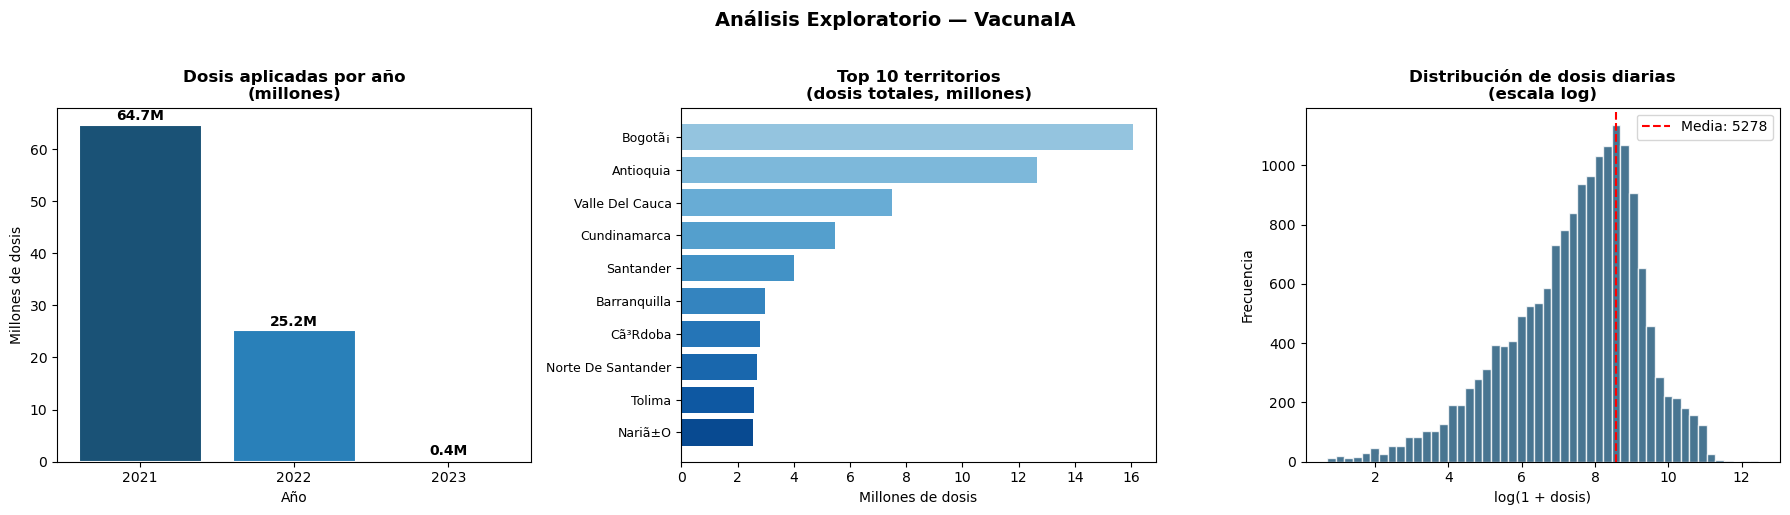


Estadísticas descriptivas de dosis aplicadas:


,Dosis aplicadas
count,17602.00
mean,5132.06
std,9273.91
min,0.00
25%,496.00
50%,2154.50
75%,5839.75
max,257038.00


In [4]:
# ============================================================
# PASO 2: ANALISIS EXPLORATORIO DE DATOS (EDA)
# ============================================================

df_eda = df.copy()
df_eda['Dosis_num'] = (
    df_eda['Cantidad_dosis_aplicadas']
    .astype(str)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
)
df_eda['Dosis_num'] = pd.to_numeric(df_eda['Dosis_num'], errors='coerce')
df_eda = df_eda.dropna(subset=['Dosis_num'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Análisis Exploratorio — VacunaIA', fontsize=14, fontweight='bold', y=1.02)

# Gráfico 1: Dosis por año
dosis_anio = df_eda.groupby('Anio')['Dosis_num'].sum() / 1_000_000
bars = axes[0].bar(dosis_anio.index.astype(str), dosis_anio.values,
                   color=[COLORS['primario'], '#2980B9', '#7FB3D3'],
                   edgecolor='white', linewidth=1.5)
axes[0].set_title('Dosis aplicadas por año\n(millones)', fontweight='bold')
axes[0].set_ylabel('Millones de dosis')
axes[0].set_xlabel('Año')
for bar, val in zip(bars, dosis_anio.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}M', ha='center', va='bottom', fontweight='bold')

# Gráfico 2: Top 10 territorios
top10 = df_eda.groupby('Nom_Territorio')['Dosis_num'].sum().nlargest(10) / 1_000_000
axes[1].barh(range(len(top10)), top10.values,
             color=plt.cm.Blues(np.linspace(0.4, 0.9, len(top10))))
axes[1].set_yticks(range(len(top10)))
axes[1].set_yticklabels(top10.index, fontsize=9)
axes[1].set_title('Top 10 territorios\n(dosis totales, millones)', fontweight='bold')
axes[1].set_xlabel('Millones de dosis')
axes[1].invert_yaxis()

# Gráfico 3: Distribución de dosis (log)
dosis_filtradas = df_eda[df_eda['Dosis_num'] > 0]['Dosis_num']
axes[2].hist(np.log1p(dosis_filtradas), bins=50, color=COLORS['primario'],
             alpha=0.8, edgecolor='white')
axes[2].set_title('Distribución de dosis diarias\n(escala log)', fontweight='bold')
axes[2].set_xlabel('log(1 + dosis)')
axes[2].set_ylabel('Frecuencia')
axes[2].axvline(np.log1p(dosis_filtradas.mean()), color='red',
                linestyle='--', label=f'Media: {dosis_filtradas.mean():.0f}')
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_vacunaia.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nEstadísticas descriptivas de dosis aplicadas:')
display(df_eda['Dosis_num'].describe().round(2).to_frame(name='Dosis aplicadas'))


### Celda 4 — Preprocesamiento y limpieza

In [5]:
# ============================================================
# PASO 3: PREPROCESAMIENTO
# ============================================================

print('PREPROCESAMIENTO DEL DATASET')
print('=' * 60)

n_original = len(df)

# 1. Eliminar duplicados
df.drop_duplicates(inplace=True)
print(f'  1. Duplicados eliminados    : {n_original - len(df):,} registros')

# 2. Eliminar columnas irrelevantes (errors='ignore' evita KeyError si ya no existen)
cols_a_eliminar = ['Fecha_aplicacion', 'Cod_Territorio', 'Fecha_corte']
df.drop(columns=[c for c in cols_a_eliminar if c in df.columns], inplace=True)
print(f'  2. Columnas activas         : {df.columns.tolist()}')

# 3. Corrección del formato numérico colombiano
# El CSV usa punto como separador de miles: '1.019' = 1019 dosis
df['Cantidad_dosis_aplicadas'] = (
    df['Cantidad_dosis_aplicadas']
    .astype(str)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
)
df['Cantidad_dosis_aplicadas'] = pd.to_numeric(df['Cantidad_dosis_aplicadas'], errors='coerce')
n_antes = len(df)
df.dropna(subset=['Cantidad_dosis_aplicadas'], inplace=True)
print(f'  3. Registros con dosis nula : {n_antes - len(df):,} eliminados')
print(f'  4. Registros finales        : {len(df):,}')

print()
print('Estadísticas tras el preprocesamiento:')
display(df['Cantidad_dosis_aplicadas'].describe().round(2).to_frame(name='Dosis aplicadas'))


PREPROCESAMIENTO DEL DATASET
  1. Duplicados eliminados    : 50 registros
  2. Columnas activas         : ['Anio', 'Nom_Territorio', 'Cantidad_dosis_aplicadas']
  3. Registros con dosis nula : 0 eliminados
  4. Registros finales        : 17,552

Estadísticas tras el preprocesamiento:


,Dosis aplicadas
count,17552.00
mean,5146.28
std,9283.25
min,0.00
25%,502.00
50%,2169.50
75%,5856.50
max,257038.00


### Celda 5 — Construcción de variable objetivo con K-Means

CLUSTERING K-MEANS — CENTROIDES Y DISTRIBUCION
  Nivel 0 - Bajo : centroide =      2,074 dosis | 14,197 registros (80.9%)
  Nivel 1 - Medio: centroide =     12,595 dosis |  2,791 registros (15.9%)
  Nivel 2 - Alto : centroide =     44,958 dosis |    564 registros (3.2%)


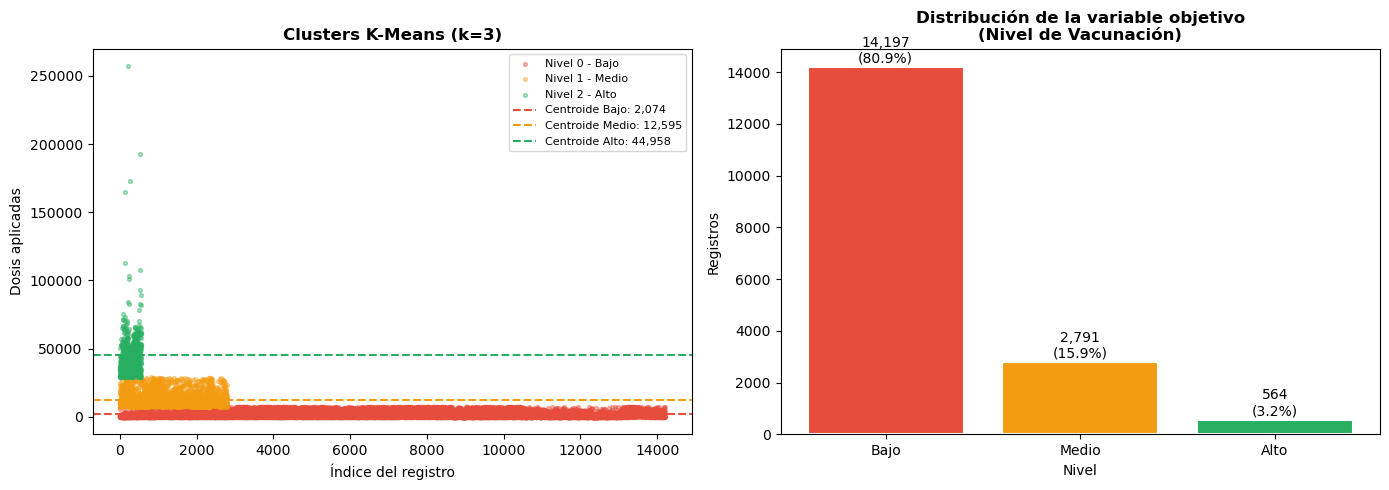

In [6]:
# ============================================================
# PASO 4: CONSTRUCCION DE LA VARIABLE OBJETIVO CON K-MEANS
# K-Means detecta grupos naturales eliminando la arbitrariedad
# de umbrales manuales: Bajo / Medio / Alto
# ============================================================

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(df[['Cantidad_dosis_aplicadas']])

centros = {i: kmeans.cluster_centers_[i][0] for i in range(3)}
orden = sorted(centros, key=lambda x: centros[x])
mapa_nivel = {orden[0]: 0, orden[1]: 1, orden[2]: 2}
df['Nivel_Vacunacion'] = df['Cluster'].map(mapa_nivel)
df.drop('Cluster', axis=1, inplace=True)

etiquetas_nivel = {0: 'Bajo', 1: 'Medio', 2: 'Alto'}
colores_nivel   = [COLORS['bajo'], COLORS['medio'], COLORS['alto']]

print('CLUSTERING K-MEANS — CENTROIDES Y DISTRIBUCION')
print('=' * 60)
centros_ordenados = sorted(centros.values())
for i, c in enumerate(centros_ordenados):
    nombre = etiquetas_nivel[i]
    cnt = (df['Nivel_Vacunacion'] == i).sum()
    pct = cnt / len(df) * 100
    print(f'  Nivel {i} - {nombre:<5}: centroide = {c:>10,.0f} dosis | {cnt:>6,} registros ({pct:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for nivel in range(3):
    mask = df['Nivel_Vacunacion'] == nivel
    axes[0].scatter(range(mask.sum()), df[mask]['Cantidad_dosis_aplicadas'],
                    c=colores_nivel[nivel], alpha=0.4, s=8,
                    label=f'Nivel {nivel} - {etiquetas_nivel[nivel]}')
for i, c in enumerate(centros_ordenados):
    axes[0].axhline(c, color=colores_nivel[i], linestyle='--', linewidth=1.5,
                    label=f'Centroide {etiquetas_nivel[i]}: {c:,.0f}')
axes[0].set_title('Clusters K-Means (k=3)', fontweight='bold')
axes[0].set_xlabel('Índice del registro')
axes[0].set_ylabel('Dosis aplicadas')
axes[0].legend(fontsize=8, loc='upper right')

conteo = df['Nivel_Vacunacion'].value_counts().sort_index()
bars = axes[1].bar([etiquetas_nivel[i] for i in conteo.index], conteo.values,
                   color=colores_nivel, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, conteo.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=10)
axes[1].set_title('Distribución de la variable objetivo\n(Nivel de Vacunación)', fontweight='bold')
axes[1].set_xlabel('Nivel')
axes[1].set_ylabel('Registros')

plt.tight_layout()
plt.savefig('clusters_kmeans.png', dpi=120, bbox_inches='tight')
plt.show()


### Celda 6 — Codificación y partición del dataset

In [7]:
# ============================================================
# PASO 5: CODIFICACION Y PARTICION DEL DATASET
# ============================================================

le = LabelEncoder()
df['Territorio_cod'] = le.fit_transform(df['Nom_Territorio'])

print('Codificación territorial (primeros 10 territorios):')
mapeo = dict(zip(le.classes_, le.transform(le.classes_)))
muestra = dict(list(mapeo.items())[:10])
display(pd.DataFrame.from_dict(muestra, orient='index', columns=['Código']).T)

X = df[['Anio', 'Territorio_cod', 'Cantidad_dosis_aplicadas']]
y = df['Nivel_Vacunacion']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nPARTICION DEL DATASET (Estratificada 80/20)')
print(f'  Entrenamiento: {len(X_train):,} registros')
print(f'  Prueba       : {len(X_test):,} registros')

print('\nDistribución de niveles:')
dist_train = y_train.value_counts(normalize=True).sort_index()
dist_test  = y_test.value_counts(normalize=True).sort_index()
for i in range(3):
    print(f'  Nivel {i} ({etiquetas_nivel[i]:<5}): Train {dist_train[i]:.1%} | Test {dist_test[i]:.1%}')


Codificación territorial (primeros 10 territorios):


,Amazonas,Antioquia,Arauca,Atlã¡Ntico,Barranquilla,Bogotã¡,Bolã­Var,Boyacã¡,Buenaventura,Caldas
Código,0,1,2,3,4,5,6,7,8,9



PARTICION DEL DATASET (Estratificada 80/20)
  Entrenamiento: 14,041 registros
  Prueba       : 3,511 registros

Distribución de niveles:
  Nivel 0 (Bajo ): Train 80.9% | Test 80.9%
  Nivel 1 (Medio): Train 15.9% | Test 15.9%
  Nivel 2 (Alto ): Train 3.2% | Test 3.2%


### Celda 7 — Entrenamiento de los 4 modelos

In [8]:
# ============================================================
# PASO 6: ENTRENAMIENTO DE 4 MODELOS SUPERVISADOS
# ============================================================

modelos = {
    'Regresion Logistica': LogisticRegression(max_iter=1000, random_state=42),
    'Arbol de Decision':   DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42),
    'KNN (k=5)':           KNeighborsClassifier(n_neighbors=5),
    'Red Neuronal (MLP)':  MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42),
}

print('Entrenando modelos...')
for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    print(f'  OK  {nombre}')

print('\nTodos los modelos entrenados correctamente.')


Entrenando modelos...
  OK  Regresion Logistica
  OK  Arbol de Decision
  OK  KNN (k=5)
  OK  Red Neuronal (MLP)

Todos los modelos entrenados correctamente.


### Celda 8 — Evaluación comparativa con validación cruzada

Modelo                          Train     Test     CV-5   F1-macro
Regresion Logistica          100.00%  100.00%   99.98%     1.0000
Arbol de Decision            100.00%  100.00%   99.99%     1.0000
KNN (k=5)                     99.99%  100.00%   99.97%     1.0000
Red Neuronal (MLP)            99.42%   99.63%   99.28%     0.9939

Modelo seleccionado: Arbol de Decision
  CV-5 Accuracy : 99.99%
  F1-macro      : 1.0000


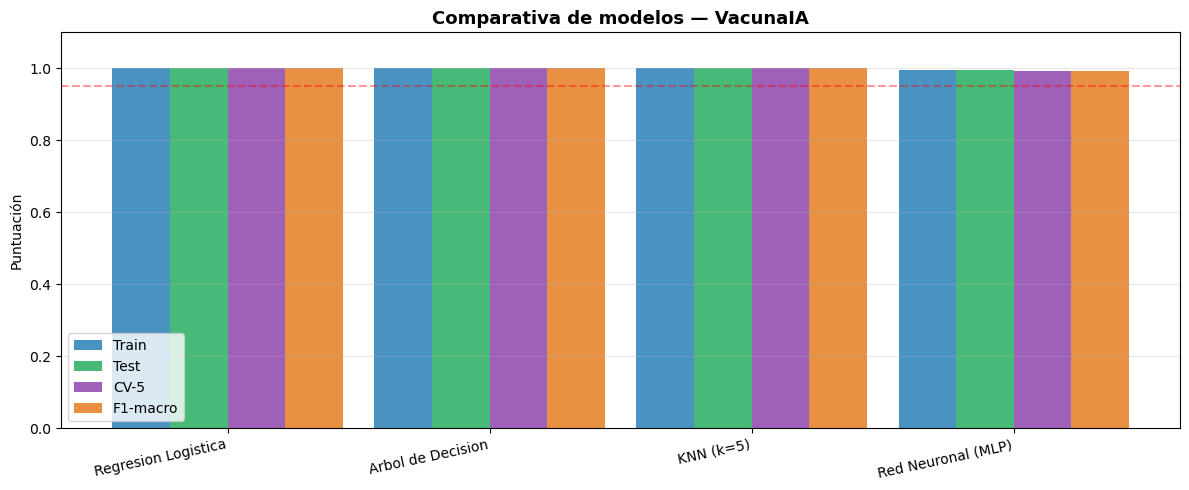

In [9]:
# ============================================================
# PASO 7: EVALUACION Y COMPARACION DE MODELOS
# Métricas: Accuracy (train/test/CV-5), F1-macro
# ============================================================

print('=' * 75)
print(f'{"Modelo":<28} {"Train":>8} {"Test":>8} {"CV-5":>8} {"F1-macro":>10}')
print('=' * 75)

resultados = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for nombre, modelo in modelos.items():
    train_acc = modelo.score(X_train, y_train)
    test_acc  = modelo.score(X_test,  y_test)
    cv_acc    = cross_val_score(modelo, X, y, cv=skf, scoring='accuracy').mean()
    y_pred_tmp = modelo.predict(X_test)
    f1         = f1_score(y_test, y_pred_tmp, average='macro')
    resultados[nombre] = {'train': train_acc, 'test': test_acc, 'cv5': cv_acc, 'f1': f1}
    print(f'{nombre:<28} {train_acc:>7.2%} {test_acc:>8.2%} {cv_acc:>8.2%} {f1:>10.4f}')

print('=' * 75)
mejor = max(resultados, key=lambda m: resultados[m]['cv5'])
print(f'\nModelo seleccionado: {mejor}')
print(f'  CV-5 Accuracy : {resultados[mejor]["cv5"]:.2%}')
print(f'  F1-macro      : {resultados[mejor]["f1"]:.4f}')

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(modelos))
w = 0.22
nombres = list(resultados.keys())

ax.bar(x - w,     [resultados[n]['train'] for n in nombres], w, label='Train',    color='#2980B9', alpha=0.85)
ax.bar(x,         [resultados[n]['test']  for n in nombres], w, label='Test',     color='#27AE60', alpha=0.85)
ax.bar(x + w,     [resultados[n]['cv5']   for n in nombres], w, label='CV-5',     color='#8E44AD', alpha=0.85)
ax.bar(x + 2*w,   [resultados[n]['f1']    for n in nombres], w, label='F1-macro', color='#E67E22', alpha=0.85)

ax.set_xticks(x + w/2)
ax.set_xticklabels(nombres, rotation=12, ha='right', fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Puntuación')
ax.set_title('Comparativa de modelos — VacunaIA', fontweight='bold', fontsize=13)
ax.legend()
ax.axhline(0.95, color='red', linestyle='--', alpha=0.4, label='Meta 95%')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('comparativa_modelos.png', dpi=120, bbox_inches='tight')
plt.show()


### Celda 9 — Reporte detallado y matriz de confusión

REPORTE DE CLASIFICACION — ARBOL DE DECISION
              precision    recall  f1-score   support

        Bajo       1.00      1.00      1.00      2840
       Medio       1.00      1.00      1.00       558
        Alto       1.00      1.00      1.00       113

    accuracy                           1.00      3511
   macro avg       1.00      1.00      1.00      3511
weighted avg       1.00      1.00      1.00      3511



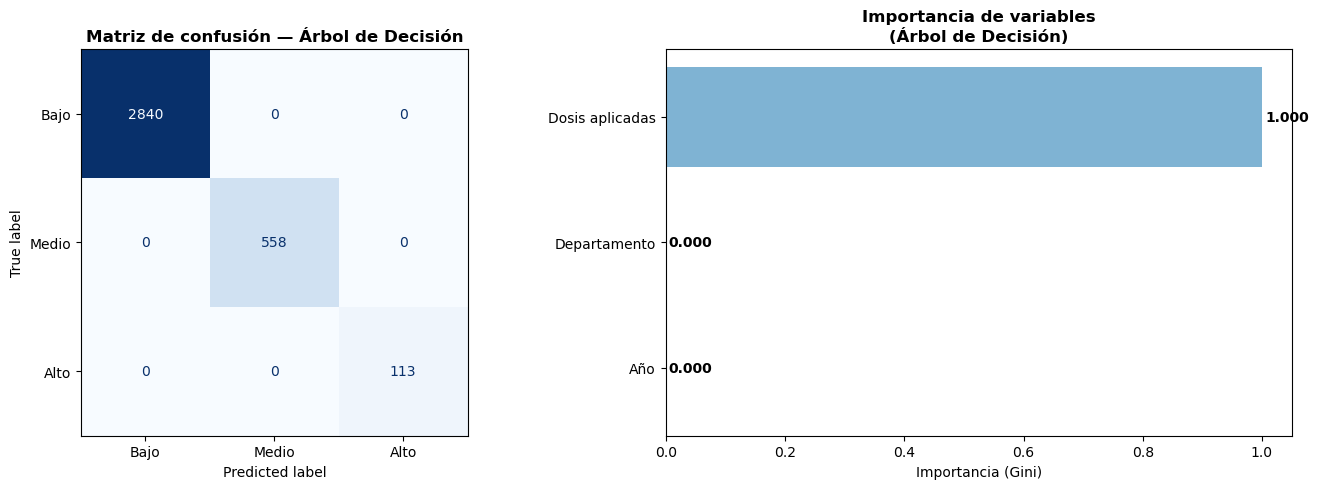

In [16]:
# ============================================================
# PASO 8: REPORTE DETALLADO — ARBOL DE DECISION
# ============================================================

AD = modelos['Arbol de Decision']
y_pred = AD.predict(X_test)

print('REPORTE DE CLASIFICACION — ARBOL DE DECISION')
print('=' * 60)
print(classification_report(y_test, y_pred, target_names=['Bajo', 'Medio', 'Alto']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bajo', 'Medio', 'Alto'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de confusión — Árbol de Decisión', fontweight='bold')

importancias = pd.Series(
    AD.feature_importances_,
    index=['Año', 'Departamento', 'Dosis aplicadas']
).sort_values(ascending=True)

axes[1].barh(importancias.index, importancias.values,
             color=[COLORS['primario'], '#2980B9', '#7FB3D3'])
axes[1].set_title('Importancia de variables\n(Árbol de Decisión)', fontweight='bold')
axes[1].set_xlabel('Importancia (Gini)')
for i, v in enumerate(importancias.values):
    axes[1].text(v + 0.005, i, f'{v:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('reporte_arbol.png', dpi=120, bbox_inches='tight')
plt.show()


### Celda 10 — Mapa de calor departamental por año

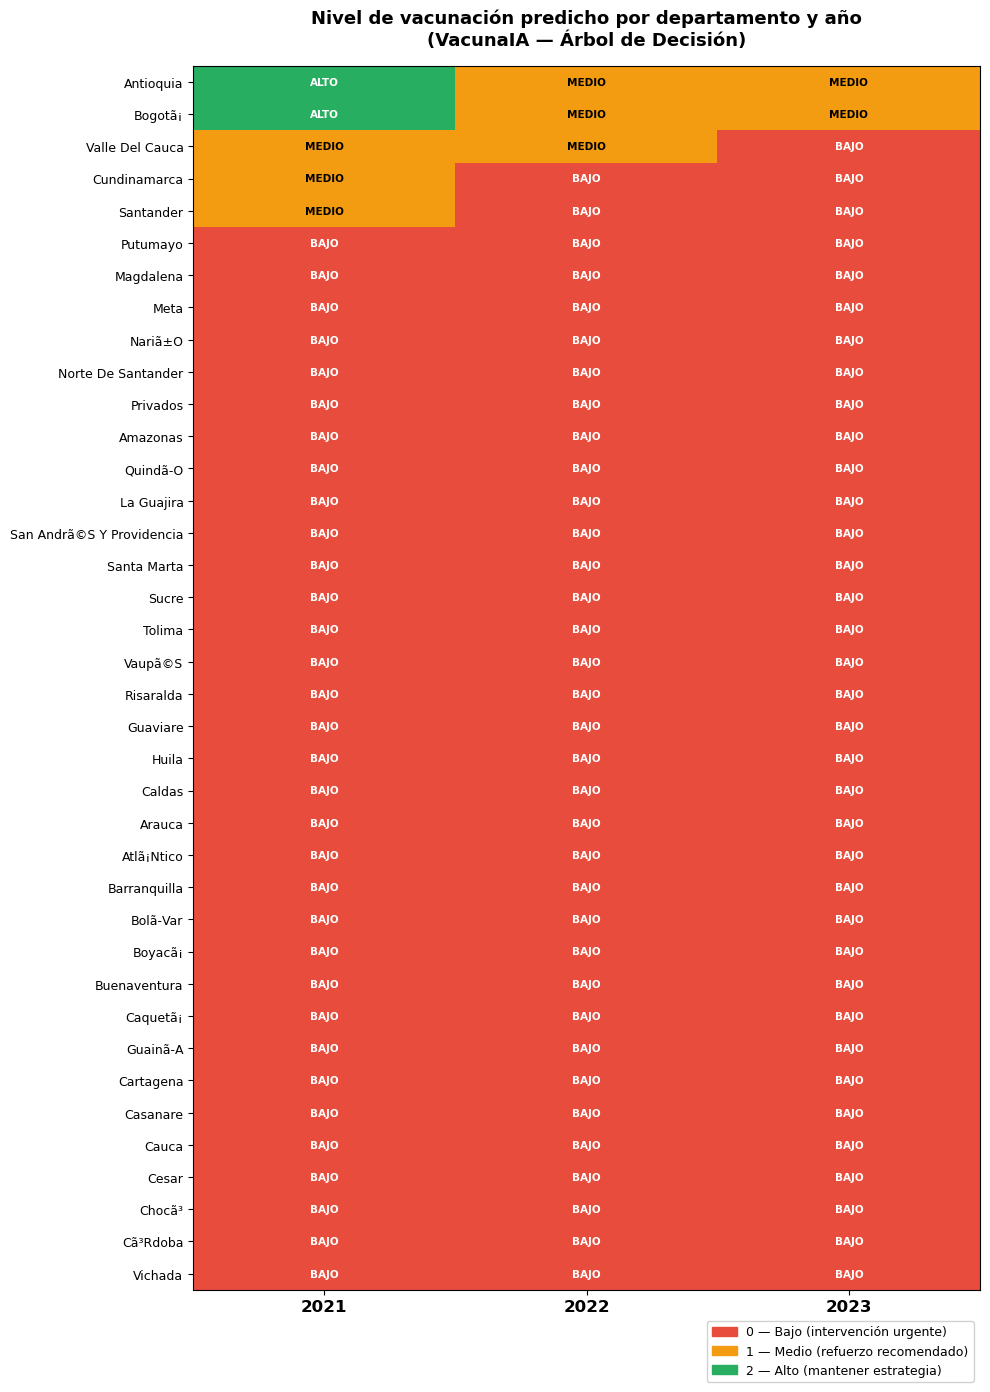

Mapa de calor guardado.


In [17]:
# ============================================================
# PASO 9: MAPA DE CALOR DEPARTAMENTAL POR ANO
# ============================================================

registros_heatmap = []
for depto in sorted(le.classes_):
    for anio in [2021, 2022, 2023]:
        cod = le.transform([depto])[0]
        dosis_prom = df[
            (df['Nom_Territorio'] == depto) & (df['Anio'] == anio)
        ]['Cantidad_dosis_aplicadas'].median()
        if pd.isna(dosis_prom):
            dosis_prom = 0
        entrada = pd.DataFrame(
            [[anio, cod, dosis_prom]],
            columns=['Anio', 'Territorio_cod', 'Cantidad_dosis_aplicadas']
        )
        nivel = AD.predict(entrada)[0]
        registros_heatmap.append({'Departamento': depto, 'Año': anio, 'Nivel': nivel})

df_heatmap = pd.DataFrame(registros_heatmap)
tabla_pivot = df_heatmap.pivot(index='Departamento', columns='Año', values='Nivel')
tabla_pivot = tabla_pivot.loc[tabla_pivot.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(10, 14))
from matplotlib.colors import ListedColormap
cmap = ListedColormap([COLORS['bajo'], COLORS['medio'], COLORS['alto']])

ax.imshow(tabla_pivot.values, cmap=cmap, vmin=0, vmax=2, aspect='auto')

ax.set_xticks(range(3))
ax.set_xticklabels([2021, 2022, 2023], fontsize=12, fontweight='bold')
ax.set_yticks(range(len(tabla_pivot)))
ax.set_yticklabels(tabla_pivot.index, fontsize=9)
ax.set_title(
    'Nivel de vacunación predicho por departamento y año\n(VacunaIA — Árbol de Decisión)',
    fontsize=13, fontweight='bold', pad=15
)

etiq = {0: 'BAJO', 1: 'MEDIO', 2: 'ALTO'}
for i in range(len(tabla_pivot)):
    for j in range(3):
        val = tabla_pivot.values[i, j]
        ax.text(j, i, etiq[int(val)], ha='center', va='center',
                fontsize=7.5, fontweight='bold',
                color='white' if val != 1 else 'black')

leyenda = [
    mpatches.Patch(color=COLORS['bajo'],  label='0 — Bajo (intervención urgente)'),
    mpatches.Patch(color=COLORS['medio'], label='1 — Medio (refuerzo recomendado)'),
    mpatches.Patch(color=COLORS['alto'],  label='2 — Alto (mantener estrategia)'),
]
ax.legend(handles=leyenda, loc='upper right', bbox_to_anchor=(1, -0.02),
          fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig('heatmap_departamental.png', dpi=120, bbox_inches='tight')
plt.show()
print('Mapa de calor guardado.')


### Celda 11 — Función de diagnóstico territorial

In [18]:
# ============================================================
# PASO 10: DIAGNOSTICO TERRITORIAL
# ============================================================

def diagnosticar_territorio(departamento: str, anio: int) -> dict:
    """
    Diagnóstico del nivel de vacunación para un departamento y año.

    Parámetros
    ----------
    departamento : nombre del departamento (tal como aparece en el dataset)
    anio         : año de interés (2021, 2022 o 2023)
    """
    if departamento not in le.classes_:
        disponibles = ', '.join(sorted(le.classes_))
        print(f'Departamento no reconocido.')
        print(f'Territorios disponibles: {disponibles}')
        return {}

    cod = le.transform([departamento])[0]
    dosis_prom = df[
        (df['Nom_Territorio'] == departamento) & (df['Anio'] == anio)
    ]['Cantidad_dosis_aplicadas'].median()
    if pd.isna(dosis_prom):
        dosis_prom = df[df['Nom_Territorio'] == departamento]['Cantidad_dosis_aplicadas'].median()

    entrada = pd.DataFrame(
        [[anio, cod, dosis_prom]],
        columns=['Anio', 'Territorio_cod', 'Cantidad_dosis_aplicadas']
    )
    resultado = AD.predict(entrada)[0]

    etiquetas = {0: 'BAJO', 1: 'MEDIO', 2: 'ALTO'}
    mensajes = {
        0: 'ALERTA: intervención urgente. Se recomienda despliegue de brigadas móviles y campaña focalizada.',
        1: 'ATENCION: desempeño moderado. Reforzar estrategias locales y mejorar acceso a puntos de vacunación.',
        2: 'OPTIMO: mantener flujo de suministros y estrategias actuales. Compartir buenas prácticas.'
    }

    print('=' * 58)
    print('  DIAGNOSTICO VacunaIA')
    print('=' * 58)
    print(f'  Departamento  : {departamento}')
    print(f'  Año           : {anio}')
    print(f'  Dosis mediana : {dosis_prom:,.0f} dosis/día')
    print(f'  Nivel         : {etiquetas[resultado]}')
    print(f'  {mensajes[resultado]}')
    print()
    print('  Comparación entre modelos:')
    for nombre, modelo in modelos.items():
        pred = modelo.predict(entrada)[0]
        marca = ' <- seleccionado' if nombre == 'Arbol de Decision' else ''
        print(f'    {nombre:<28}: {etiquetas[pred]}{marca}')
    print('=' * 58)

    return {
        'departamento': departamento,
        'anio': anio,
        'nivel': resultado,
        'etiqueta': etiquetas[resultado],
        'diagnostico': mensajes[resultado]
    }


# Ejemplos de diagnóstico
_ = diagnosticar_territorio('Barranquilla', 2022)
print()
_ = diagnosticar_territorio('Chocó', 2021)
print()
_ = diagnosticar_territorio('Bogotá D.C.', 2023)


  DIAGNOSTICO VacunaIA
  Departamento  : Barranquilla
  Año           : 2022
  Dosis mediana : 3,669 dosis/día
  Nivel         : BAJO
  ALERTA: intervención urgente. Se recomienda despliegue de brigadas móviles y campaña focalizada.

  Comparación entre modelos:
    Regresion Logistica         : BAJO
    Arbol de Decision           : BAJO <- seleccionado
    KNN (k=5)                   : BAJO
    Red Neuronal (MLP)          : BAJO

Departamento no reconocido.
Territorios disponibles: Amazonas, Antioquia, Arauca, Atlã¡Ntico, Barranquilla, Bogotã¡, Bolã­Var, Boyacã¡, Buenaventura, Caldas, Caquetã¡, Cartagena, Casanare, Cauca, Cesar, Chocã³, Cundinamarca, Cã³Rdoba, Guainã­A, Guaviare, Huila, La Guajira, Magdalena, Meta, Nariã±O, Norte De Santander, Privados, Putumayo, Quindã­O, Risaralda, San Andrã©S Y Providencia, Santa Marta, Santander, Sucre, Tolima, Valle Del Cauca, Vaupã©S, Vichada

Departamento no reconocido.
Territorios disponibles: Amazonas, Antioquia, Arauca, Atlã¡Ntico, Barranqu

### Celda 12 — Diagnóstico masivo (2023)

In [19]:
# ============================================================
# PASO 11: DIAGNOSTICO MASIVO — TODOS LOS DEPARTAMENTOS (2023)
# ============================================================

print('DIAGNOSTICO TERRITORIAL — AÑO 2023')
print('=' * 55)

resultados_masivos = []
for depto in sorted(le.classes_):
    cod = le.transform([depto])[0]
    dosis_prom = df[
        (df['Nom_Territorio'] == depto) & (df['Anio'] == 2023)
    ]['Cantidad_dosis_aplicadas'].median()
    if pd.isna(dosis_prom):
        dosis_prom = 0
    entrada = pd.DataFrame(
        [[2023, cod, dosis_prom]],
        columns=['Anio', 'Territorio_cod', 'Cantidad_dosis_aplicadas']
    )
    nivel = AD.predict(entrada)[0]
    iconos_nivel = {0: '[BAJO] ', 1: '[MEDIO]', 2: '[ALTO] '}
    print(f'  {iconos_nivel[nivel]}  {depto}')
    resultados_masivos.append({'Departamento': depto, 'Nivel': nivel, 'Etiqueta': etiquetas_nivel[nivel]})

df_resumen = pd.DataFrame(resultados_masivos)
print()
print('Resumen por nivel:')
print(df_resumen.groupby('Etiqueta').size().to_frame('Departamentos'))


DIAGNOSTICO TERRITORIAL — AÑO 2023
  [BAJO]   Amazonas
  [MEDIO]  Antioquia
  [BAJO]   Arauca
  [BAJO]   Atlã¡Ntico
  [BAJO]   Barranquilla
  [MEDIO]  Bogotã¡
  [BAJO]   Bolã­Var
  [BAJO]   Boyacã¡
  [BAJO]   Buenaventura
  [BAJO]   Caldas
  [BAJO]   Caquetã¡
  [BAJO]   Cartagena
  [BAJO]   Casanare
  [BAJO]   Cauca
  [BAJO]   Cesar
  [BAJO]   Chocã³
  [BAJO]   Cundinamarca
  [BAJO]   Cã³Rdoba
  [BAJO]   Guainã­A
  [BAJO]   Guaviare
  [BAJO]   Huila
  [BAJO]   La Guajira
  [BAJO]   Magdalena
  [BAJO]   Meta
  [BAJO]   Nariã±O
  [BAJO]   Norte De Santander
  [BAJO]   Privados
  [BAJO]   Putumayo
  [BAJO]   Quindã­O
  [BAJO]   Risaralda
  [BAJO]   San Andrã©S Y Providencia
  [BAJO]   Santa Marta
  [BAJO]   Santander
  [BAJO]   Sucre
  [BAJO]   Tolima
  [BAJO]   Valle Del Cauca
  [BAJO]   Vaupã©S
  [BAJO]   Vichada

Resumen por nivel:
          Departamentos
Etiqueta               
Bajo                 36
Medio                 2


### Celda 13 — Visualización del Árbol de Decisión

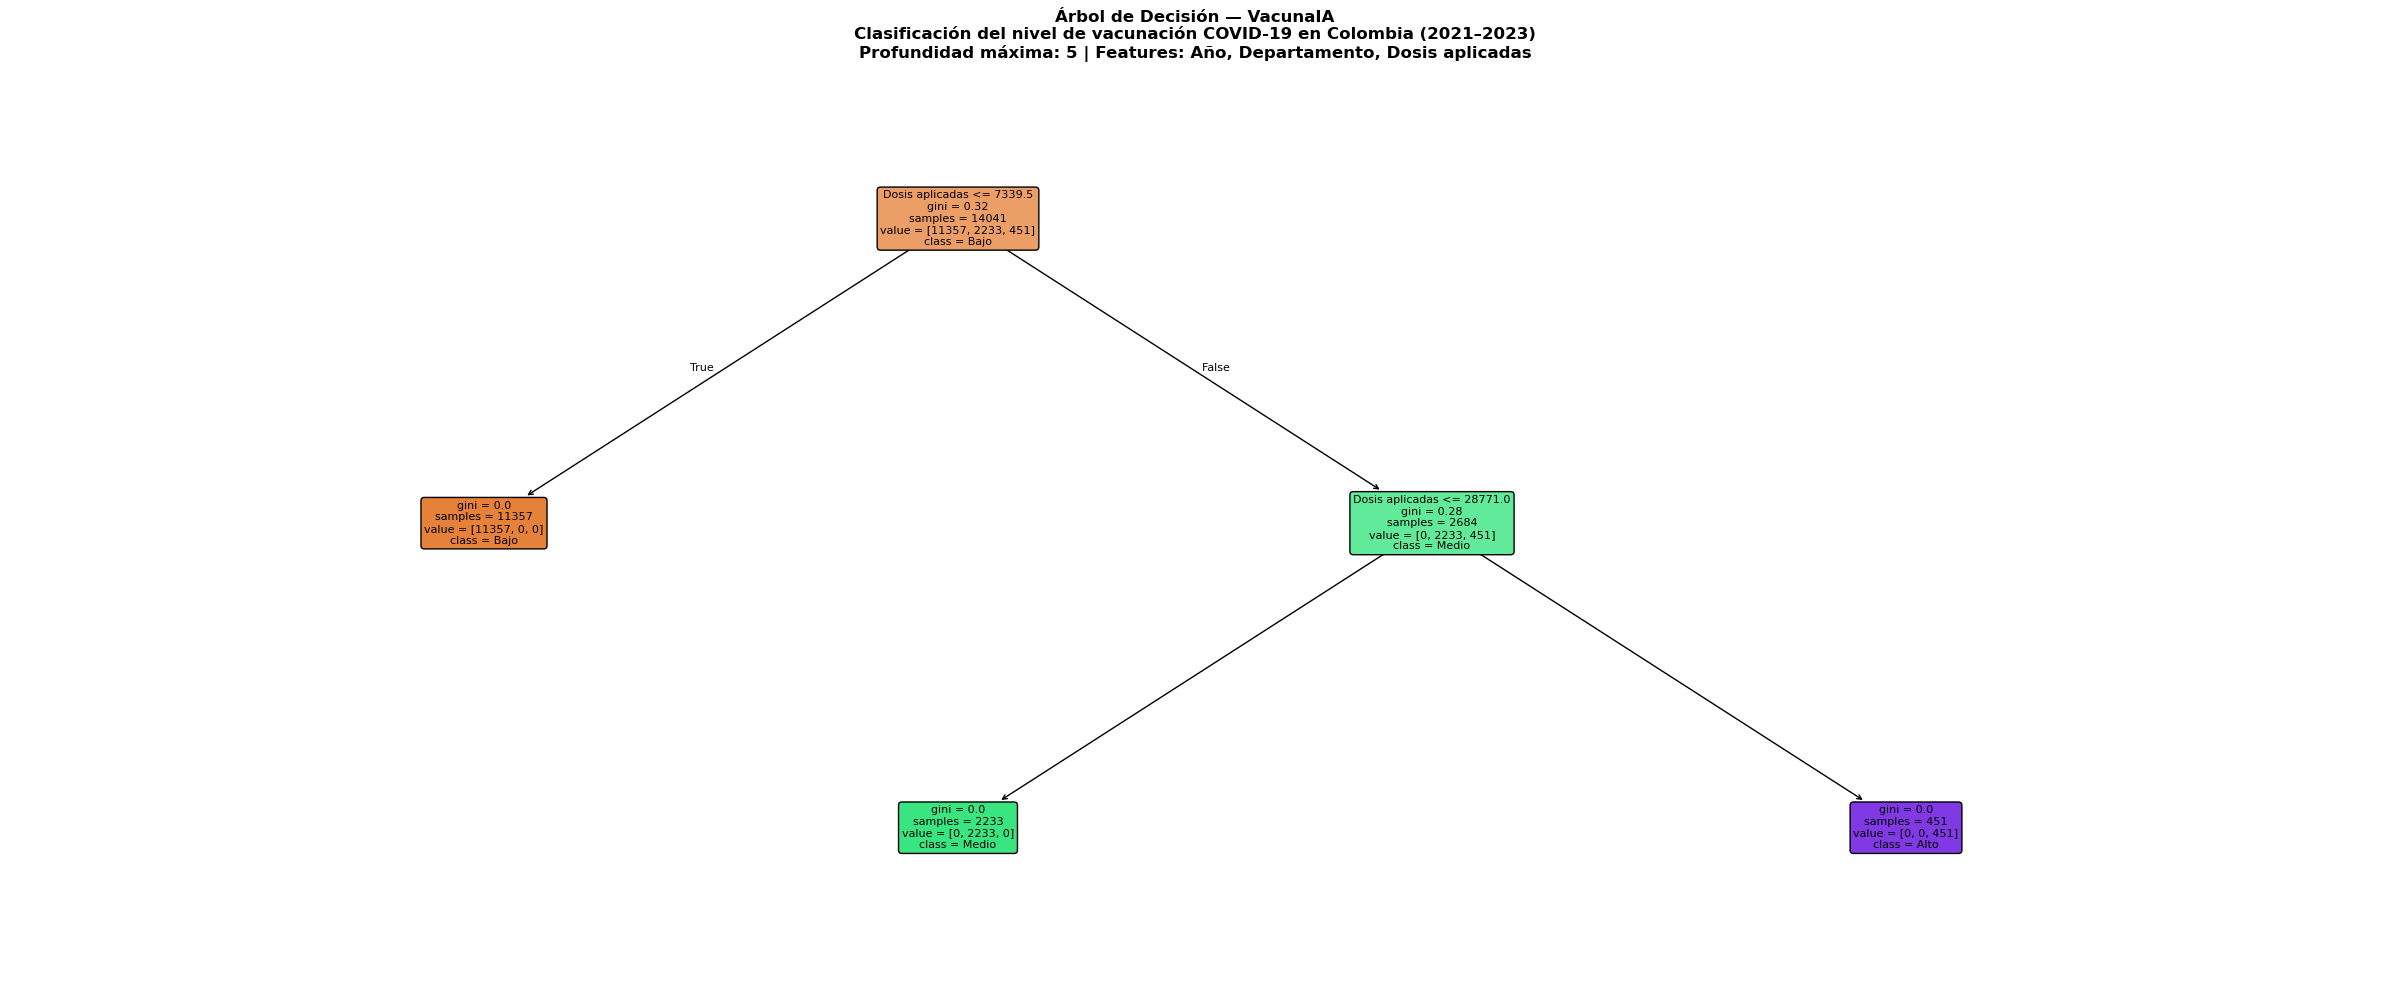

Árbol de decisión guardado.


In [20]:
# ============================================================
# PASO 12: VISUALIZACION DEL ARBOL DE DECISION
# ============================================================

fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(
    AD,
    feature_names=['Año', 'Departamento', 'Dosis aplicadas'],
    class_names=['Bajo', 'Medio', 'Alto'],
    filled=True,
    rounded=True,
    fontsize=8,
    precision=2,
    ax=ax,
    impurity=True
)
ax.set_title(
    'Árbol de Decisión — VacunaIA\n'
    'Clasificación del nivel de vacunación COVID-19 en Colombia (2021–2023)\n'
    'Profundidad máxima: 5 | Features: Año, Departamento, Dosis aplicadas',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('arbol_decision_vacunaia.png', dpi=120, bbox_inches='tight')
plt.show()
print('Árbol de decisión guardado.')
